In [1]:
#series(1-d)
#dataframe(2-d)

In [2]:
#Multiindex Series
index_val=[('cse',2019),('cse',2020),('ece',2019),('ece',2020)]

In [3]:
import numpy as np
import pandas as pd
a1=pd.Series([1,2,3,4],index=index_val)
#stay1 type

In [4]:
a1['cse',2020]

2

In [5]:
#multiIndexing(hierarchical indexing)
#Correct way of multiindexing
index_val=[('cse',2019),('cse',2020),('ece',2019),('cse',2019),('cse',2020),('ece',2021),('ece',2021)]

In [6]:
index_val

[('cse', 2019),
 ('cse', 2020),
 ('ece', 2019),
 ('cse', 2019),
 ('cse', 2020),
 ('ece', 2021),
 ('ece', 2021)]

In [7]:
multiindex=pd.MultiIndex.from_tuples(index_val)

In [8]:
type(multiindex)

pandas.core.indexes.multi.MultiIndex

In [9]:
m1=pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])

In [10]:
s=pd.Series([1,2,3,4,5,6,7,8],index=m1)

In [11]:
#2-dimensional series in multiindexing
s['cse',2022]

4

In [12]:
s.info()

<class 'pandas.core.series.Series'>
MultiIndex: 8 entries, ('cse', 2019) to ('ece', 2022)
Series name: None
Non-Null Count  Dtype
--------------  -----
8 non-null      int64
dtypes: int64(1)
memory usage: 740.0+ bytes


In [13]:
temp=s.unstack()

In [14]:
temp.stack()

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [15]:
#convert high dimension into series or dataframe

In [16]:
#multiIndex dataframe
#Branch/Year-Pack 120

In [17]:
df1=pd.DataFrame([
    [1,2],[2,3],[3,4],[4,5],[5,6],[6,7],[7,8],[8,9]
],index=m1,columns=['avg_package','strength'])

In [18]:
df1.loc['ece']

,avg_package,strength
2019,5,6
2020,6,7
2021,7,8
2022,8,9


In [19]:
df1['strength']

cse  2019    2
     2020    3
     2021    4
     2022    5
ece  2019    6
     2020    7
     2021    8
     2022    9
Name: strength, dtype: int64

In [20]:
branch_df2 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
    ],
    index = [2019,2020,2021,2022],
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

branch_df2

delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [21]:
branch_df2.loc[2019].reset_index()

,level_0,level_1,2019
0,delhi,avg_package,1
1,delhi,students,2
2,mumbai,avg_package,0
3,mumbai,students,0


In [22]:
# Multiindex df in terms of both cols and index

branch_df3 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = m1,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [23]:
branch_df3.loc[('cse',2019),('delhi','avg_package')]

1

In [24]:
branch_df3.loc[('ece',2022),('delhi','avg_package')]

15

## stacking and unstacking

In [25]:
df1.unstack()

avg_package                strength               
           2019 2020 2021 2022     2019 2020 2021 2022
cse           1    2    3    4        2    3    4    5
ece           5    6    7    8        6    7    8    9

In [26]:
branch_df2.stack().stack()

C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\2534568903.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df2.stack().stack()


2019  avg_package  delhi     1
                   mumbai    0
      students     delhi     2
                   mumbai    0
2020  avg_package  delhi     3
                   mumbai    0
      students     delhi     4
                   mumbai    0
2021  avg_package  delhi     5
                   mumbai    0
      students     delhi     6
                   mumbai    0
2022  avg_package  delhi     7
                   mumbai    0
      students     delhi     8
                   mumbai    0
dtype: int64

In [27]:
branch_df3.stack().stack()

C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\4023844418.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df3.stack().stack()


cse  2019  avg_package  delhi      1
                        mumbai     0
           students     delhi      2
                        mumbai     0
     2020  avg_package  delhi      3
                        mumbai     0
           students     delhi      4
                        mumbai     0
     2021  avg_package  delhi      5
                        mumbai     0
           students     delhi      6
                        mumbai     0
     2022  avg_package  delhi      7
                        mumbai     0
           students     delhi      8
                        mumbai     0
ece  2019  avg_package  delhi      9
                        mumbai     0
           students     delhi     10
                        mumbai     0
     2020  avg_package  delhi     11
                        mumbai     0
           students     delhi     12
                        mumbai     0
     2021  avg_package  delhi     13
                        mumbai     0
           students     delhi     14
 

In [28]:
#Arranging technique as per requirement
#pivot table is different as it does aggregation

## working with multiindex dataframes

In [29]:
branch_df2.head()

delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [30]:
branch_df3.shape

(8, 4)

In [31]:
branch_df3.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('cse', 2019) to ('ece', 2022)
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   (delhi, avg_package)   8 non-null      int64
 1   (delhi, students)      8 non-null      int64
 2   (mumbai, avg_package)  8 non-null      int64
 3   (mumbai, students)     8 non-null      int64
dtypes: int64(4)
memory usage: 932.0+ bytes


In [32]:
branch_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 2019 to 2022
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   (delhi, avg_package)   4 non-null      int64
 1   (delhi, students)      4 non-null      int64
 2   (mumbai, avg_package)  4 non-null      int64
 3   (mumbai, students)     4 non-null      int64
dtypes: int64(4)
memory usage: 332.0 bytes


In [33]:
branch_df3.duplicated()

cse  2019    False
     2020    False
     2021    False
     2022    False
ece  2019    False
     2020    False
     2021    False
     2022    False
dtype: bool

In [34]:
branch_df3.isnull()

delhi               mumbai         
         avg_package students avg_package students
cse 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False
ece 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False

In [35]:
branch_df3.describe()

delhi                 mumbai         
      avg_package   students avg_package students
count    8.000000   8.000000         8.0      8.0
mean     8.000000   9.000000         0.0      0.0
std      4.898979   4.898979         0.0      0.0
min      1.000000   2.000000         0.0      0.0
25%      4.500000   5.500000         0.0      0.0
50%      8.000000   9.000000         0.0      0.0
75%     11.500000  12.500000         0.0      0.0
max     15.000000  16.000000         0.0      0.0

In [36]:
## extracting single rows
branch_df3.loc[('cse',2022)]

delhi   avg_package    7
        students       8
mumbai  avg_package    0
        students       0
Name: (cse, 2022), dtype: int64

In [37]:
#multiple rows
branch_df3.loc[('cse',2019):('ece',2020):2]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

In [38]:
##using iloc
branch_df3.iloc[0:5:2]


delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

In [39]:
branch_df3['delhi']['avg_package']

cse  2019     1
     2020     3
     2021     5
     2022     7
ece  2019     9
     2020    11
     2021    13
     2022    15
Name: avg_package, dtype: int64

In [40]:
branch_df2['delhi']['students']

2019    2
2020    4
2021    6
2022    8
Name: students, dtype: int64

In [41]:
branch_df3.iloc[:,1:3]

delhi      mumbai
         students avg_package
cse 2019        2           0
    2020        4           0
    2021        6           0
    2022        8           0
ece 2019       10           0
    2020       12           0
    2021       14           0
    2022       16           0

In [42]:
#extracting both
branch_df3.iloc[[0,4],[1,2]]

,,delhi,mumbai
,,students,avg_package
cse,2019,2,0
ece,2019,10,0


In [43]:
#sort
branch_df3.sort_index(ascending=False)

delhi               mumbai         
         avg_package students avg_package students
ece 2022          15       16           0        0
    2021          13       14           0        0
    2020          11       12           0        0
    2019           9       10           0        0
cse 2022           7        8           0        0
    2021           5        6           0        0
    2020           3        4           0        0
    2019           1        2           0        0

In [44]:
branch_df3.sort_index(ascending=[False,True])

delhi               mumbai         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

In [45]:
branch_df3.sort_index(level=1,ascending=False)

delhi               mumbai         
         avg_package students avg_package students
ece 2022          15       16           0        0
cse 2022           7        8           0        0
ece 2021          13       14           0        0
cse 2021           5        6           0        0
ece 2020          11       12           0        0
cse 2020           3        4           0        0
ece 2019           9       10           0        0
cse 2019           1        2           0        0

In [46]:
branch_df3.transpose()

cse                 ece               
                   2019 2020 2021 2022 2019 2020 2021 2022
delhi  avg_package    1    3    5    7    9   11   13   15
       students       2    4    6    8   10   12   14   16
mumbai avg_package    0    0    0    0    0    0    0    0
       students       0    0    0    0    0    0    0    0

In [47]:
branch_df3.swaplevel(axis=1)

avg_package students avg_package students
               delhi    delhi      mumbai   mumbai
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

Wide format is where we have a single row for every data point with multiple columns to hold the values of various attributes.

Long format is where, for each data point we have as many rows as the number of attributes and each row contains the value of a particular attribute for a given data point.

In [48]:
# melt -> simple example branch
# wide to long
pd.DataFrame({'cse':[120]}).melt()

,variable,value
0,cse,120


In [49]:
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'A': ['John', 'Boby', 'Mina', 'Peter', 'Nicky'],
    'B': ['Masters', 'Graduate', 'Graduate', 'Masters', 'Graduate'],
    'C': [27, 23, 21, 23, 24]
})
table = pd.pivot_table(df, values='C', index='C', columns='B', aggfunc='sum')
print(table)

B  Graduate Masters
C                  
21     Mina     NaN
23     Boby   Peter
24    Nicky     NaN
27      NaN    John


In [50]:
pd.DataFrame({'cse':[120],'ece':[100]}).melt(var_name='branch',value_name='students')

,branch,students
0,cse,120
1,ece,100


In [51]:
pd.DataFrame(
    {
        'branch':['cse','ece','mech'],
        '2020':[100,150,60],
        '2021':[120,130,80],
        '2022':[150,140,70]
    }).melt(id_vars=['branch'],var_name='year',value_name='students')

,branch,year,students
0,cse,2020,100
1,ece,2020,150
2,mech,2020,60
3,cse,2021,120
4,ece,2021,130
5,mech,2021,80
6,cse,2022,150
7,ece,2022,140
8,mech,2022,70


In [52]:
confirm=pd.read_csv('time_series_covid19_confirmed_global.csv')
death=pd.read_csv('time_series_covid19_deaths_global.csv')

In [53]:
confirm.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


In [54]:
death.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [55]:
death.shape
#wide format

(289, 1081)

In [56]:
confirm.shape
#wide format

(289, 1081)

In [57]:
#Country 
#Date
#Confirmed 
#Deaths 
#Covid-19

In [58]:
death=death.melt(id_vars=['Province/State','Country/Region','Lat','Long'],value_name='num_deaths',var_name='date')

In [59]:
confirm=confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'],value_name='num_deaths',var_name='date')

In [61]:
confirm.merge(death,on=['Country/Region','Lat','Long','date'])

,Province/State_x,Country/Region,Lat,Long,date,num_deaths_x,Province/State_y,num_deaths_y
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0,NaN,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0,NaN,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0,NaN,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0,NaN,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0,NaN,0
...,...,...,...,...,...,...,...,...
313402,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,703228,NaN,5708
313403,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,535,NaN,0
313404,NaN,Yemen,15.552727,48.516388,1/2/23,11945,NaN,2159
313405,NaN,Zambia,-13.133897,27.849332,1/2/23,334661,NaN,4024


## Pivot-Table

In [62]:
import numpy as np
import pandas as pd
import seaborn as sns

In [63]:
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [64]:
#Categorical and Numerical Columns

In [69]:
#q1 Avg total bill by gender
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\3420037647.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [68]:
df.groupby(['sex'])[['total_bill']].mean()

C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\4201317724.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex'])[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [70]:
df.pivot_table(values='total_bill',index='sex',columns='smoker')

C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\158333279.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(values='total_bill',index='sex',columns='smoker')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [76]:
df.pivot_table(values='total_bill',index='sex',columns='smoker',aggfunc='median')

C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\4052022683.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(values='total_bill',index='sex',columns='smoker',aggfunc='median')


smoker,Yes,No
sex,,
Male,20.39,18.24
Female,16.27,16.69


In [81]:
df.pivot_table(values=['tip','total_bill'],index='sex',columns='smoker',aggfunc='sum')

C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\3038876864.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(values=['tip','total_bill'],index='sex',columns='smoker',aggfunc='sum')


tip         total_bill         
smoker     Yes      No        Yes       No
sex                                       
Male    183.07  302.00    1337.07  1919.75
Female   96.74  149.77     593.27   977.68

In [85]:
# multidimensional
df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'},margins=True)


C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\902678551.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'},margins=True)


size                                                 \
day                Thur              Fri                 Sat       Sun   
time              Lunch Dinner     Lunch    Dinner    Dinner    Dinner   
sex    smoker                                                            
Male   Yes     2.300000    NaN  1.666667  2.400000  2.629630  2.600000   
       No      2.500000    NaN       NaN  2.000000  2.656250  2.883721   
Female Yes     2.428571    NaN  2.000000  2.000000  2.200000  2.500000   
       No      2.500000    2.0  3.000000  2.000000  2.307692  3.071429   
All            2.459016    2.0  2.000000  2.166667  2.517241  2.842105   

                          tip               ...       total_bill         \
day                 All  Thur          Fri  ...   All       Thur          
time                    Lunch Dinner Lunch  ...            Lunch Dinner   
sex    smoker                               ...                           
Male   Yes     2.500000  5.00    NaN  2.20  ...  10.0     191.71   0.00   
       No      2.711340  6.70    NaN   NaN  ...   9.0     369.73   0.00   
Female Yes     2.242424  5.00    NaN  3.48  ...   6.5     134.53   0.00   
       No      2.592593  5.17    3.0  3.00  ...   5.2     381.58  18.78   
All            2.569672  6.70    3.0  3.48  ...  10.0    1077.55  18.78   

                                                                     
day              Fri           Sat            Sun               All  
time           Lunch  Dinner Lunch   Dinner Lunch   Dinner           
sex    smoker                                                        
Male   Yes     34.16  129.46   0.0   589.62   0.0   392.12  1337.07  
       No       0.00   34.95   0.0   637.73   0.0   877.34  1919.75  
Female Yes     39.78   48.80   0.0   304.00   0.0    66.16   593.27  
       No      15.98   22.75   0.0   247.05   0.0   291.54   977.68  
All            89.92  235.96   NaN  1778.40   NaN  1627.16  4827.77  

[5 rows x 23 columns]

C:\Users\swaya\AppData\Local\Temp\ipykernel_13412\3650233965.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True).plot(kind='bar')


<Axes: xlabel='sex'>

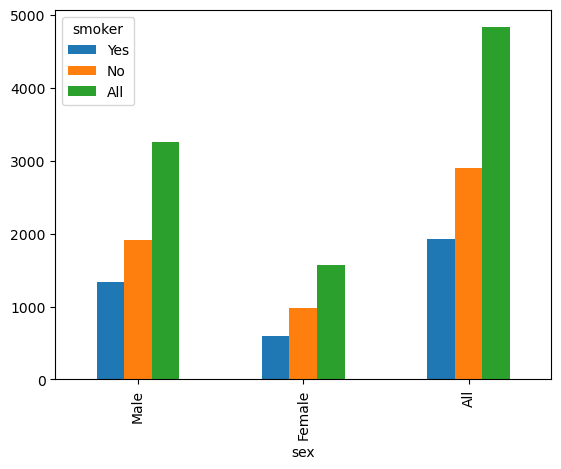

In [89]:
# margins
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True).plot(kind='bar')